# 03 Competitive Benchmarking
### Imports and pulling data from the database

In [54]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

import sys
from pathlib import Path

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# PCA for visualization
from sklearn.decomposition import PCA

SRC_PATH = Path.cwd().parent / "src"
sys.path.append(str(SRC_PATH))

In [55]:
# Importing data from DB
conn = sqlite3.connect("../data/reviews_analysis.db")

hotels_df = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

tables = hotels_df['name'].tolist()

# Create empty dictionary
dataset = {}

# Query all data from every tables
for table in tables:
    query = f"SELECT * FROM {table}"
    dataset[table] = pd.read_sql(query, conn)

conn.close() # Close the connection after fetching data

We already have aggregated hotel data during the data preperation phase that is:
- grouped by hotel id
- on the same scale from 1 to 5

which means that the data is mostly ready for clustering for further analysis.

From [Siteminder hotel classifications](https://www.siteminder.com/r/hotel-classifications/), the main differences between the different star-hotels are services and room quality. Location should also factor into the equation.

Features used for clustering:
- avg_service_rating
- avg location_rating
- avg_rooms_rating

Overall rating corresponds with the above features (except location rating) from EDA, so is likely a composite of other features and thus is not as useful. Value rating is value for money and not a direct indication of how much the customers  paid for the hotel and hence is not that useful as it also correlates with the above ratings.

From a quick research scan, sleep quality rating, check in rating, and business service rating are not as key features in determining hotel type.


In [56]:
FEATURES = ['avg_service_rating', 'avg_location_rating', 'avg_rooms_rating']
hotels = dataset['hotels'].dropna(subset=FEATURES).copy() #ensuring no NA values in the features of interest
print(f"{len(dataset['hotels']):,} hotels")

hotels.head()

3,380 hotels


,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating,kmeans_cluster,PCA1,PCA2
0,214197,1825,2.363836,2.306301,2.261370,2.617534,4.433425,2.595794,2.065205,2.421053,2.265306,2,-2.096394,2.051411
1,122005,1774,3.911499,4.221533,3.949267,3.858512,4.665163,4.098581,3.717587,3.623377,3.843137,1,0.596673,0.731115
2,93520,1739,3.522714,3.600920,3.550316,3.557217,4.687752,3.813973,3.456009,2.994012,2.568182,1,0.103088,1.087507
3,93562,1685,4.252819,4.217804,4.077151,4.016617,4.670623,3.936960,3.997033,4.369369,3.757576,0,1.088570,0.425062
4,93618,1647,3.993321,4.101396,3.828780,3.408622,4.602914,4.099425,3.680631,4.134328,3.474359,1,0.583312,0.629585


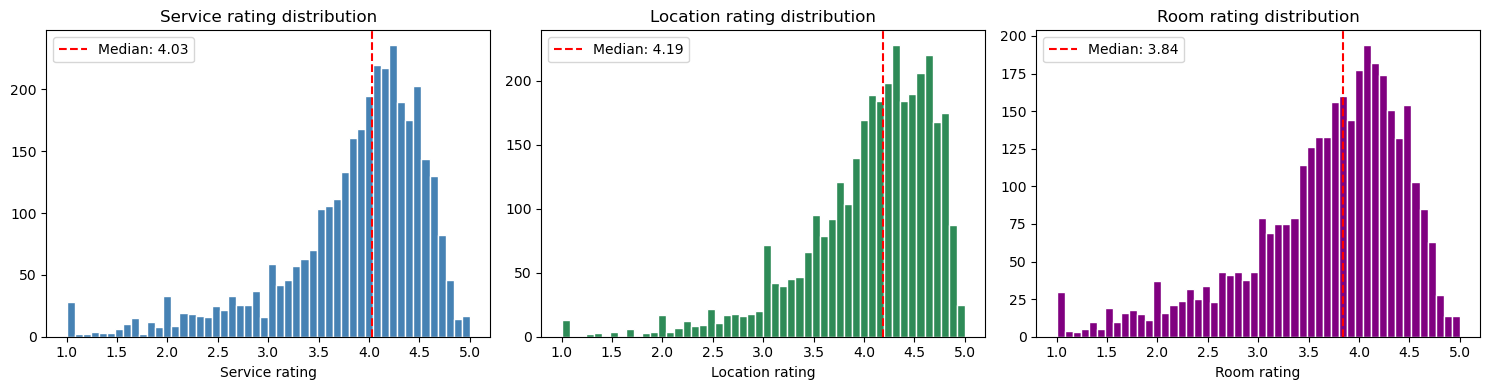

In [57]:
# Quick EDA visualizations to understand distributions of features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Service Rating
axes[0].hist(hotels['avg_service_rating'], bins=50, edgecolor='white', color='steelblue')
axes[0].set_xlabel('Service rating')
axes[0].set_title('Service rating distribution')
axes[0].axvline(hotels['avg_service_rating'].median(), color='red', linestyle='--', label=f'Median: {hotels["avg_service_rating"].median():.2f}')
axes[0].legend()

# Location Rating
axes[1].hist(hotels['avg_location_rating'], bins=50, edgecolor='white', color='seagreen')
axes[1].set_xlabel('Location rating')
axes[1].set_title('Location rating distribution')
axes[1].axvline(hotels['avg_location_rating'].median(), color='red', linestyle='--', label=f'Median: {hotels["avg_location_rating"].median():.2f}')
axes[1].legend()

# Rooms Rating
axes[2].hist(hotels['avg_rooms_rating'], bins=50, edgecolor='white', color='purple')
axes[2].set_xlabel('Room rating')
axes[2].set_title('Room rating distribution')
axes[2].axvline(hotels['avg_rooms_rating'].median(), color='red', linestyle='--', label=f'Median: {hotels["avg_rooms_rating"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

In [58]:
X = hotels[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures prepared and standardized")
print(f"   Shape: {X_scaled.shape}")
print(f"   Features: {FEATURES}")
print(f"\nBefore scaling (first row): {X[0].round(2)}")
print(f"After scaling (first row):  {X_scaled[0].round(2)}")


Features prepared and standardized
   Shape: (3380, 3)
   Features: ['avg_service_rating', 'avg_location_rating', 'avg_rooms_rating']

Before scaling (first row): [2.36 4.43 2.07]
After scaling (first row):  [-2.03  0.58 -2.04]


In [59]:
# Finding Optimal k using Elbow + Silhouette

# Testing k-range from 2 to 10
k_range = range(2, 11)
inertias = []
silhouettes = []

print("Testing k values...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Append the inertia (within-cluster sum of squares) to the inertias list. 
    # Lower inertia = more compact clusters
    inertias.append(kmeans.inertia_)
    
    # Calculate the silhouette score, which measures how similar an object is to its own cluster compared to other clusters. 
    # Higher silhouette  = better defined clusters
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)

    print(f"  k={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={sil:.3f}")

print(f"\nBest k by silhouette: {list(k_range)[np.argmax(silhouettes)]} (score: {max(silhouettes):.3f})")

Testing k values...
  k=2: Inertia=4,342, Silhouette=0.566
  k=3: Inertia=2,862, Silhouette=0.419
  k=4: Inertia=2,259, Silhouette=0.344
  k=5: Inertia=1,936, Silhouette=0.337
  k=6: Inertia=1,672, Silhouette=0.323
  k=7: Inertia=1,492, Silhouette=0.320
  k=8: Inertia=1,357, Silhouette=0.288
  k=9: Inertia=1,241, Silhouette=0.289
  k=10: Inertia=1,143, Silhouette=0.289

Best k by silhouette: 2 (score: 0.566)


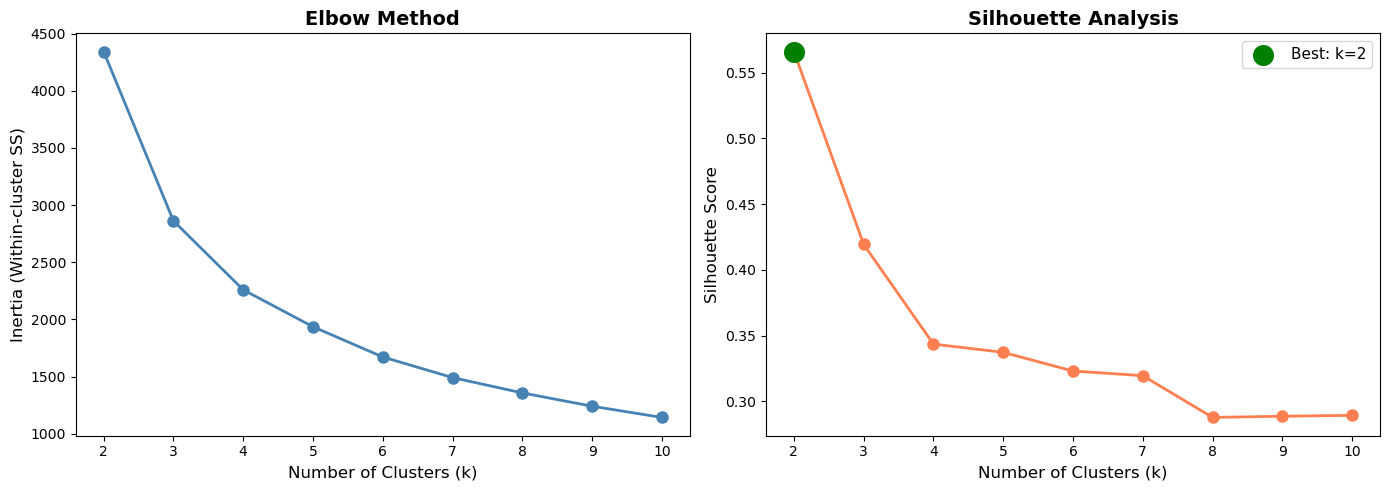

In [60]:
# Visualize Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster SS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(k_range))

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, 'o-', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(k_range))

# Highlight best k
best_k_idx = np.argmax(silhouettes)
axes[1].scatter([list(k_range)[best_k_idx]], [silhouettes[best_k_idx]],
                s=200, c='green', zorder=5, label=f'Best: k={list(k_range)[best_k_idx]}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Based on exploratory visualizations, choosing k with a value of 5. Enough segments for business to analyze, and still high enough silhouette score.

In [61]:
# Fit Final K-Means Model

CHOSEN_K = 5

kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to data
hotels['kmeans_cluster'] = kmeans_labels

# Check cluster sizes
cluster_sizes = hotels['kmeans_cluster'].value_counts().sort_index()
print(f"K-Means Cluster Sizes (k={CHOSEN_K}):")
print("-" * 30)
for cluster, size in cluster_sizes.items():
    print(f"  Cluster {cluster}: {size:,} customers ({size/len(hotels)*100:.1f}%)")

print(f"\nSilhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")

K-Means Cluster Sizes (k=5):
------------------------------
  Cluster 0: 1,242 customers (36.7%)
  Cluster 1: 658 customers (19.5%)
  Cluster 2: 510 customers (15.1%)
  Cluster 3: 212 customers (6.3%)
  Cluster 4: 758 customers (22.4%)

Silhouette Score: 0.337


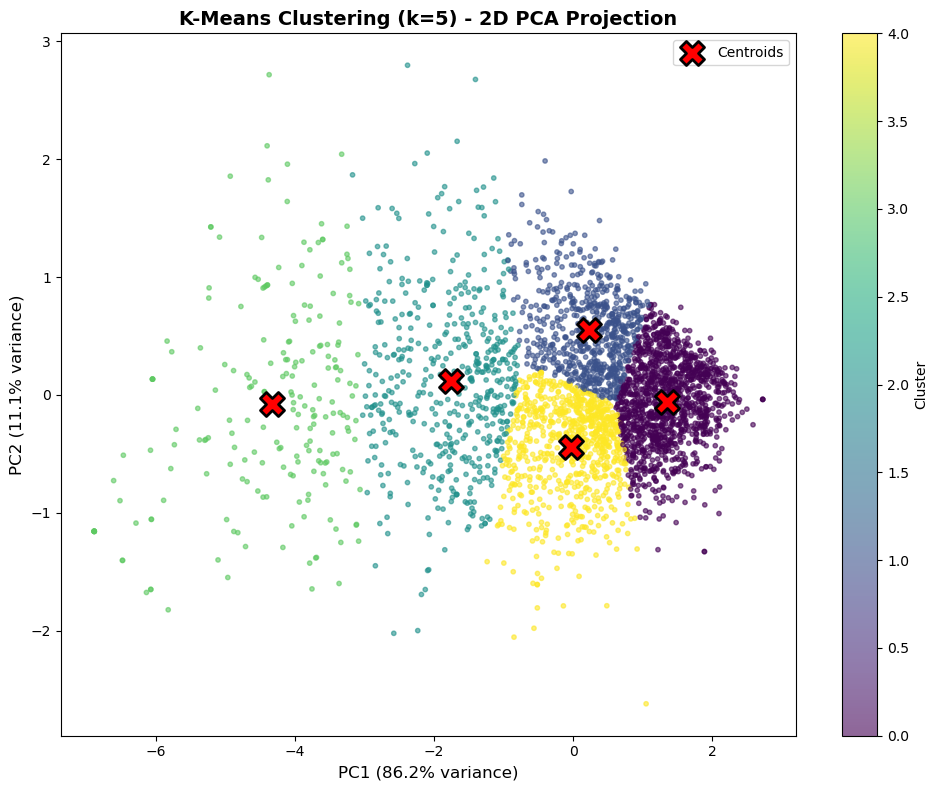

In [62]:
# Visualize clusters in 2D using PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

# Save PCA components back to hotels dataframe for future use
hotels['PCA1'] = X_pca[:, 0]
hotels['PCA2'] = X_pca[:, 1]

# Plot clusters
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                     cmap='viridis', alpha=0.6, s=10)

# Plot centroids
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2,
           label='Centroids')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title(f'K-Means Clustering (k={CHOSEN_K}) - 2D PCA Projection', fontsize=14, fontweight='bold')

plt.colorbar(scatter, label='Cluster')
ax.legend()
plt.tight_layout()
plt.show()

### Cluster profiling
Cluster profiling for business analysis

In [63]:
# Using K-Means clusters for profiling
profile = hotels.groupby('kmeans_cluster')[FEATURES].agg(['mean', 'median', 'std']).round(2)
print("Cluster Profiles (K-Means):")
display(profile)

Cluster Profiles (K-Means):


avg_service_rating              avg_location_rating         \
                             mean median   std                mean median   
kmeans_cluster                                                              
0                            4.43   4.43  0.21                4.50   4.52   
1                            3.83   3.86  0.27                4.44   4.43   
2                            3.08   3.13  0.40                3.50   3.53   
3                            1.93   2.00  0.54                2.49   2.54   
4                            3.97   4.00  0.26                3.81   3.87   

                     avg_rooms_rating               
                 std             mean median   std  
kmeans_cluster                                      
0               0.25             4.34   4.33  0.25  
1               0.21             3.58   3.62  0.30  
2               0.44             2.79   2.83  0.40  
3               0.66             1.73   1.75  0.47  
4               0.27             3.78   3.80  0.30

In [64]:
# Compute Indexes (Relative to Average)

overall_means = hotels[FEATURES].mean()

# Calculate the mean of each feature for each individual cluster.
cluster_means = hotels.groupby('kmeans_cluster')[FEATURES].mean()

# Calculate the index for each cluster and feature.
# The index is (Cluster Mean / Overall Mean) * 100, rounded to the nearest integer.
index = (cluster_means / overall_means * 100).round(0).astype(int)

# Add the count of hotels in each cluster to the index DataFrame.
index['size'] = hotels.groupby('kmeans_cluster').size()

# Add the percentage of total hotels that each cluster represents.
index['pct'] = (index['size'] / len(hotels) * 100).round(1)

print("\n Cluster Index (100 = average):")
print("="*60)
display(index)


 Cluster Index (100 = average):


,avg_service_rating,avg_location_rating,avg_rooms_rating,size,pct
kmeans_cluster,,,,,
0,115,111,118,1242,36.7
1,99,109,98,658,19.5
2,80,86,76,510,15.1
3,50,61,47,212,6.3
4,103,94,103,758,22.4


### Break down per cluster

- **Top of the line** (Cluster 0, 36.7% of hotels)
  - These are the best hotels, with above average scores in every category. Likely at least a 3-star hotel, if not 4 or 5 star.
  - Continue to do what they are doing, and marketing should emphasize their excellent review scores.
- **Convenient** (Cluster 1, 19.5% of hotels)
  - Slightly below average, no-frills hotels that stand out because of their good location ratings. The opposite of cluster 4 (**good, but inconvenient** hotels)
  - Location is key for these hotels, and should be the most important feature in their marketing.
- **Below average** (Cluster 2, 15.1% of hotels)
  - Hotels that are below average in every rating, but not as bad as the terrible hotels.
  - Improve service and room quality first before tackling convenince factor.
- **Terrible** (Cluster 3, 6.3% of hotels)
  - These are the worst hotels, with especially low room and service ratings.
  - Reorganize the management of the hotel, then start improving room quality (with a score of 47, this is less than half the average of all hotels)
- **Good, but inconvenient** (Cluster 4, 22.4% of hotels)
  - Slightly above average hotels that are situated in more out of the way areas. The opposite of cluster 4 (**convenient** hotels)
  - These hotels are harder to get to (e.g. beach resort), but are very good otherwise. Offering free transport options (hotel pick-up) can be a good way of enticing travellers to come here.



In [65]:
# Cleanup and save cluster analysis data back to DB
conn = sqlite3.connect("../data/reviews_analysis.db")

# Save the hotels DataFrame with PCA1, PCA2 and cluster labels back to hotel table for visualization and future use
hotels.to_sql("hotels", conn, if_exists="replace", index=False)

conn.close()

### Summary and learnings

Tested with and without **value rating** and does not seem to shift the analysis that much. Seems quite correlative with **room and service ratings**.

Also tested with and without **cleanliness rating** and does not seem to shift the analysis much. Seems correlative with **room rating**. Both of this can be double checked against the previous EDA analysis done.

Because the data is relatively clean and maps well to well-defined categories, k-means clustering seems a good approach to the dataset rather than HDBSCAN.